In [81]:
!pip install qiskit
!pip install qiskit-aer

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Basics

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

In [3]:
# Registers
qr = QuantumRegister(2, name='q')
cr = ClassicalRegister(2, name='c')

# Registers build circuits
qc = QuantumCircuit(qr, cr)

# Single qbit gates
qc.h(qr[0])

# Two qbit gates
# qc.cx(qr[0], qr[1])

# Measure qr, write into cr
qc.measure(qr, cr)
qc.draw()

┌───┐┌─┐
q_0: ┤ H ├┤M├
     └┬─┬┘└╥┘
q_1: ─┤M├──╫─
      └╥┘  ║ 
c: 2/══╩═══╩═
       1   0

In [4]:
from qiskit_aer import AerSimulator

In [5]:
# Simulation
backend = AerSimulator(method='statevector')
job = backend.run(qc, shots=100)
results = job.result()
counts = results.get_counts()

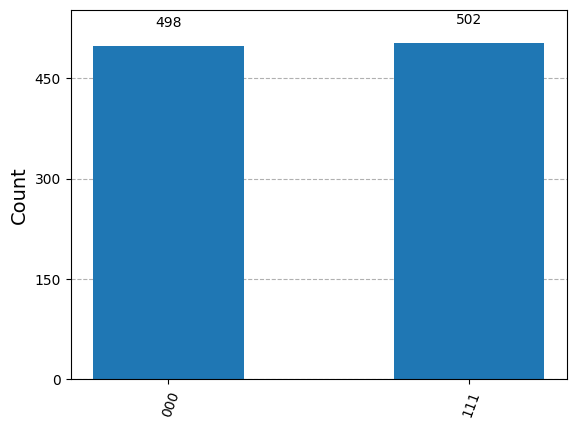

In [76]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [7]:
qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()
qc.draw()

┌───┐ ░ ┌─┐
     q: ┤ H ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0

In [8]:
backend = AerSimulator(method='statevector')
job = backend.run(qc, shots=100)
results = job.result()
counts = results.get_counts()

In [9]:
counts

{'0': 56, '1': 44}

## Drawing

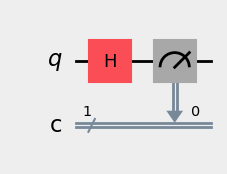

In [82]:
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)
circuit_drawer(qc, output="mpl", style={"backgroundcolor": "#EEEEEE"})

## Exercises

In [74]:
# Ex 1
# 0 -> 1
qc = QuantumCircuit(1)
qc.x(0)
qc.measure_all()
qc.draw()

┌───┐ ░ ┌─┐
     q: ┤ X ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0

In [11]:
backend = AerSimulator(method='statevector')
job = backend.run(qc, shots=100)
results = job.result()
counts = results.get_counts()
counts

{'1': 100}

In [12]:
# Ex 2
qc = QuantumCircuit(1)
qc.z(0)
qc.measure_all()
qc.draw()

┌───┐ ░ ┌─┐
     q: ┤ Z ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0

In [13]:
backend = AerSimulator(method='statevector')
job = backend.run(qc, shots=100)
counts = job.result().get_counts()
counts

{'0': 100}

In [75]:
# Ex 3
# HZH = X

## Bell states

$\ket{\Phi^+} = \frac{1}{\sqrt{2}} \left(\ket{00} + \ket{11}\right)$

$\ket{\Phi^-} = \frac{1}{\sqrt{2}} \left(\ket{00} - \ket{11}\right)$

$\ket{\Psi^+} = \frac{1}{\sqrt{2}} \left(\ket{01} + \ket{10}\right)$

$\ket{\Psi^+} = \frac{1}{\sqrt{2}} \left(\ket{01} - \ket{10}\right)$

In [68]:
from qiskit.visualization import plot_state_city
from qiskit.quantum_info import Statevector
# Statevector = [a, b, c, d] ~ [00, 01, 10, 11]
# So for phi+, sv = 1/sqrt(2) [1, 0, 0, 1]

In [69]:
# Bell states
# phi+
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# Can't get state vector after measurement
# qc.measure_all()
qc.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

In [71]:
state = Statevector.from_instruction(qc)
state

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [55]:
# phi-
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.z(1)
qc.draw()

┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐┌───┐
q_1: ─────┤ X ├┤ Z ├
          └───┘└───┘

In [66]:
state = Statevector.from_instruction(qc)
state

Statevector([ 0.        +0.j,  0.70710678+0.j, -0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))


In [57]:
# psi+
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.draw()

┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐┌───┐
q_1: ─────┤ X ├┤ X ├
          └───┘└───┘

In [58]:
state = Statevector.from_instruction(qc)
state

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


In [62]:
# phi-
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(1)
qc.draw()

┌───┐               
q_0: ┤ H ├──■────────────
     └───┘┌─┴─┐┌───┐┌───┐
q_1: ─────┤ X ├┤ X ├┤ Z ├
          └───┘└───┘└───┘

In [63]:
state = Statevector.from_instruction(qc)
state

Statevector([ 0.        +0.j,  0.70710678+0.j, -0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))


## Swap gate

In [17]:
qc = QuantumCircuit(2)
qc.x(0)
qc.swap(0, 1)
qc.measure_all()
qc.draw()

┌───┐    ░ ┌─┐   
   q_0: ┤ X ├─X──░─┤M├───
        └───┘ │  ░ └╥┘┌─┐
   q_1: ──────X──░──╫─┤M├
                 ░  ║ └╥┘
meas: 2/════════════╩══╩═
                    0  1

In [18]:
backend = AerSimulator(method='statevector')
job = backend.run(qc, shots=100)
counts = job.result().get_counts()
counts

{'10': 100}

## 3D maximally entangled states

In [72]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.measure_all()

In [73]:
backend = AerSimulator(method='statevector')
job = backend.run(qc, shots=1000)
counts = job.result().get_counts()
counts

{'000': 498, '111': 502}